In [76]:
import numpy as np
import  pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')



In [77]:
df = pd.read_csv('Data\StudentsPerformance.csv')

In [78]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [79]:
df.shape

(1000, 8)

## Data Checks to Perform

1. Check Missing Values
2. Check Duplicates
3. Check data type
4. Check the number of unique values of each column
5. Check statistics of data set
6. Check Various Categories present in the different categorized column


## Check for missing values

In [80]:
df.isnull().sum()
## no missing valoues present

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [81]:
df[df.duplicated()]   ## there are no duplicate values

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [82]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [83]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [84]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [85]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [86]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [87]:
df['lunch'].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [88]:
df.nunique()


gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## Check Statistics


In [89]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insight 

From above description of numerical data, all means are very close to each other - between 66 and 68.05;

.
 All standard deviations are also close - between 14.6 and 15.19;


. While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher=17

In [ ]:
#define numeerical and categorical features

numeric_features= [feature for feature in df.columns if df[feature] != 'O']
categorical_features= [feature for feature in df.columns if df[feature].dtype == 'O']


SyntaxError: invalid syntax (4007927403.py, line 4)

In [ ]:
## Adding Total Score and Average Score

df['Total_Score']= df['math score'] + df['writing score'] + df['reading score']
df['Average_Score']= df["Total_Score"]/3

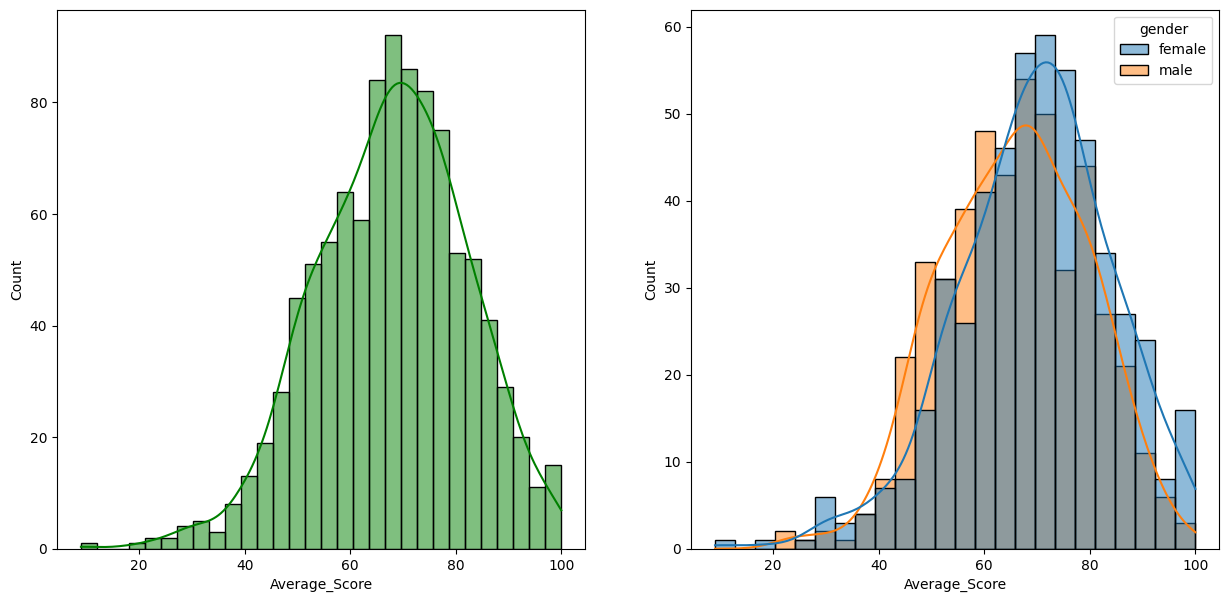

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt. subplot(121)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average_Score' ,kde=True, hue='gender')
plt.show()

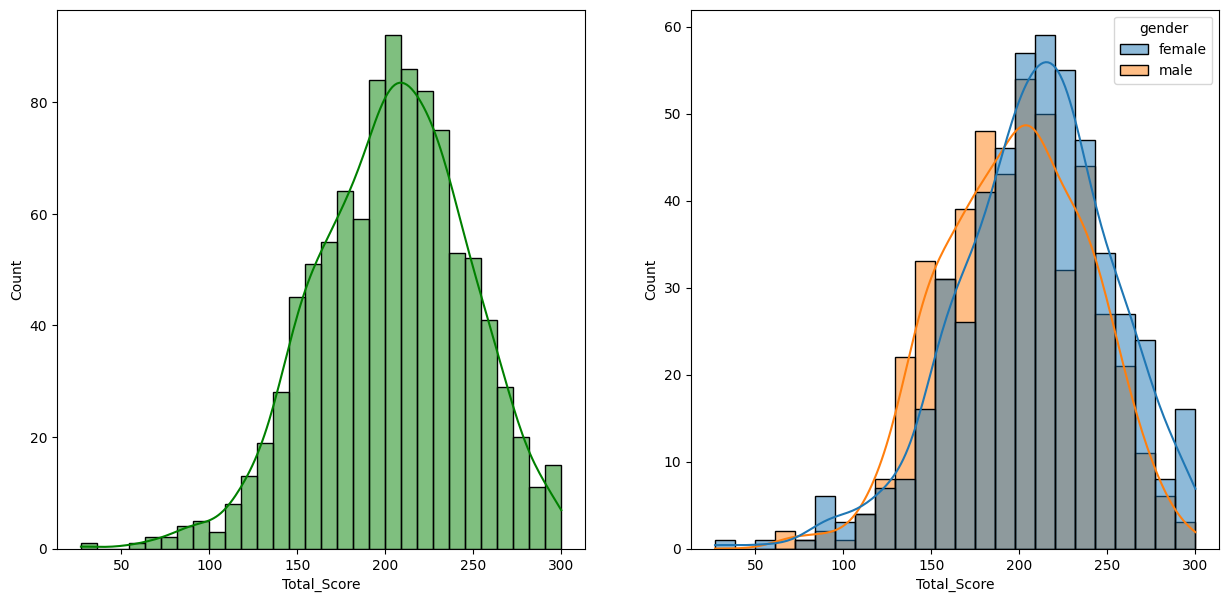

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt. subplot(121)
sns.histplot(data=df,x='Total_Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total_Score' ,kde=True, hue='gender')
plt.show()

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total_Score', 'Average_Score'],
      dtype='str')

In [ ]:
reading_full = df[df['reading score'] == 100]['Average_Score'].count()
print(f'Number of students with full marks in Reading: {reading_full}')


Number of students with full marks in Reading: 17


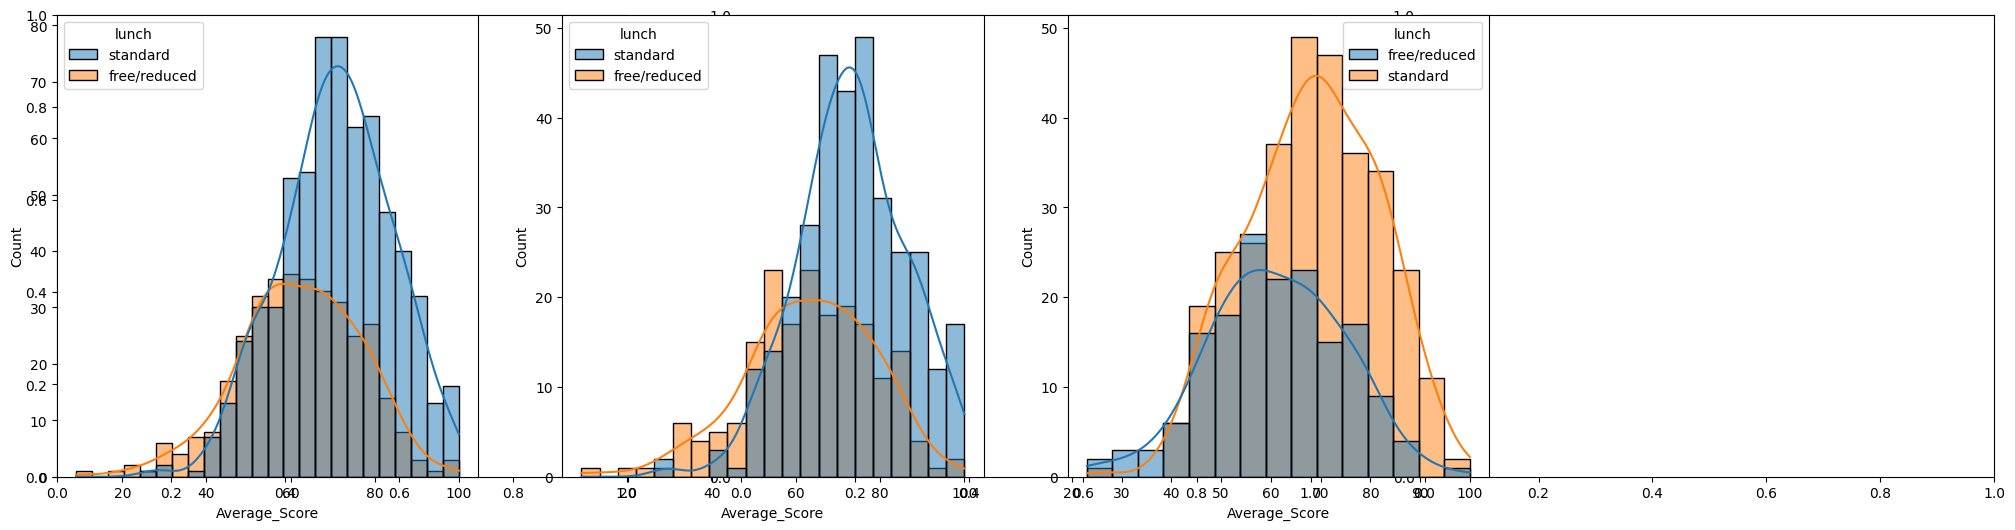

In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot (data=df,x='Average_Score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female' ],x='Average_Score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x='Average_Score',kde=True,hue='lunch')
plt.show()